# 04. Retrieval-Augmented Generation and Evaluation

This notebook moves from an LLM model to an LLM **system**. It builds a transparent retrieval-augmented generation (RAG) pipeline that retrieves relevant document chunks before asking a language model to answer.

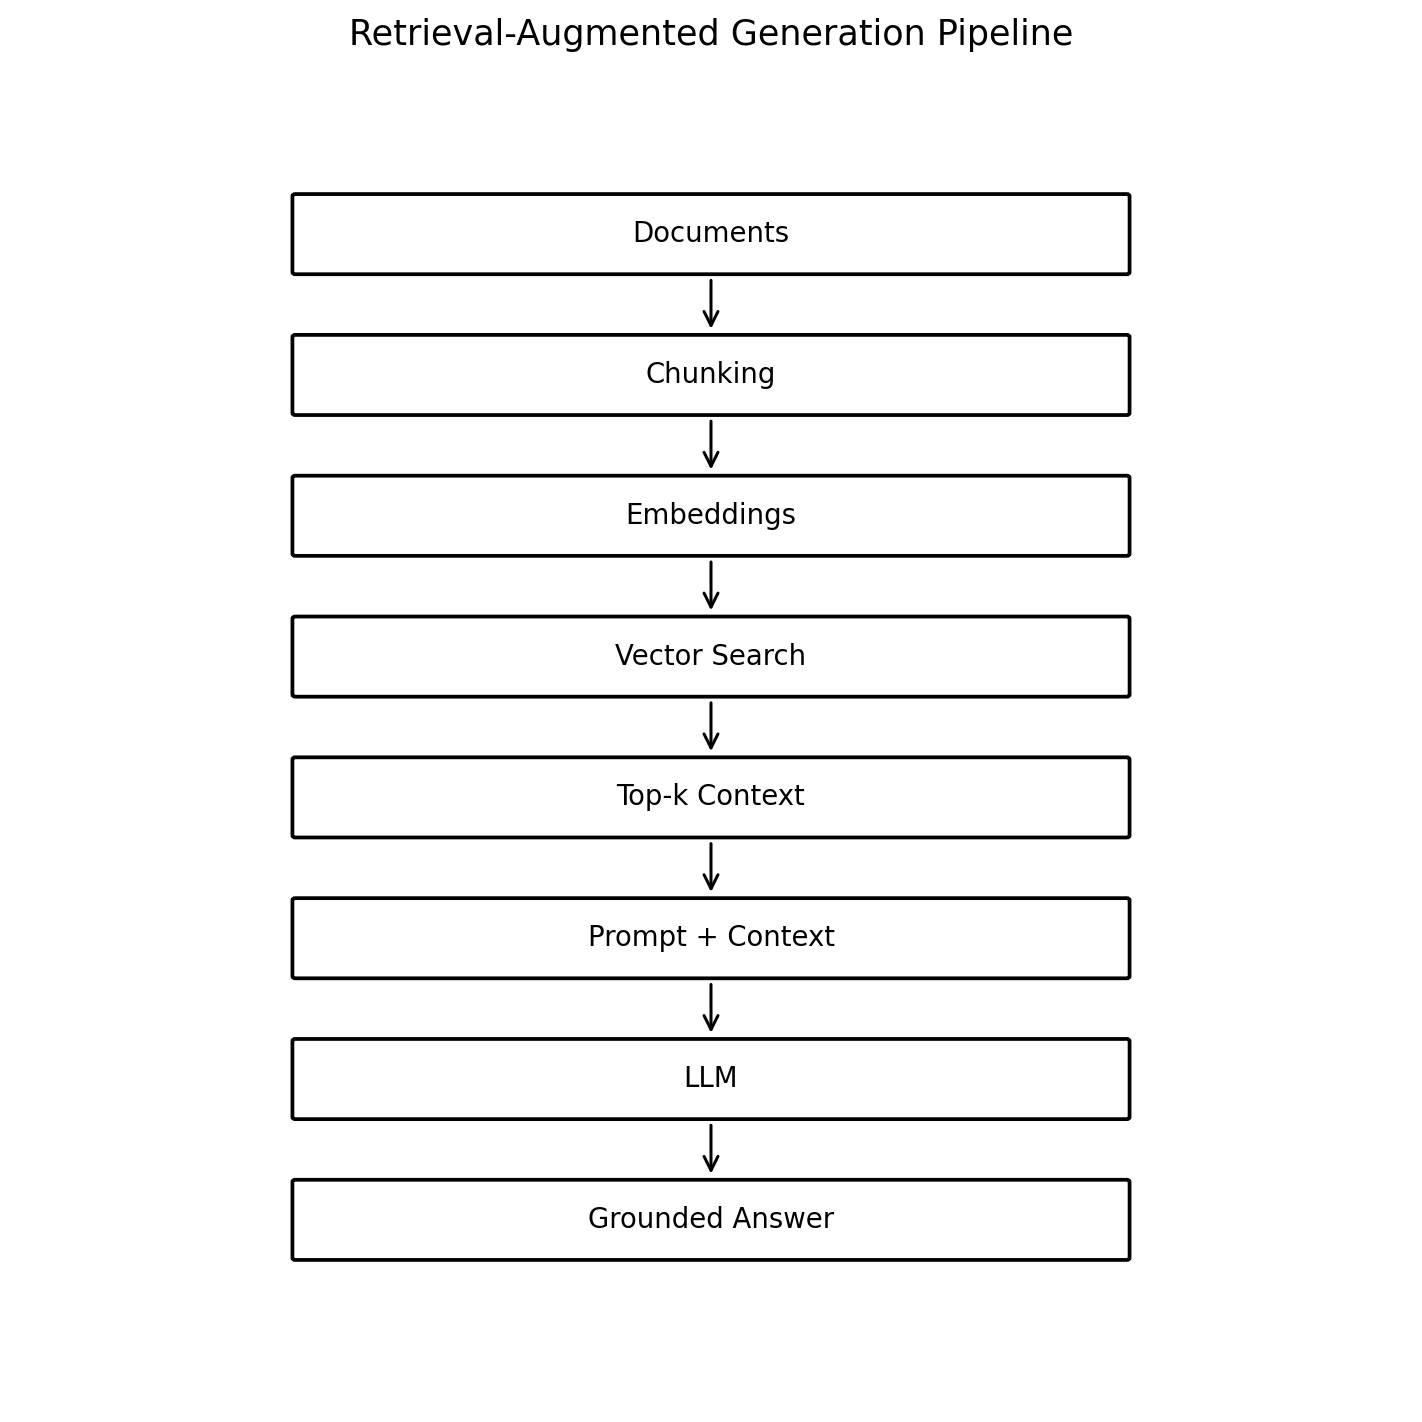

## Learning Objectives

- explain why RAG is useful,
- distinguish parametric model knowledge from retrieved external knowledge,
- create a small document corpus,
- chunk documents and understand chunk overlap,
- embed documents and queries,
- compute cosine similarity,
- retrieve top-k chunks,
- construct a context-grounded prompt,
- compare generation with and without retrieval,
- evaluate retrieval separately from answer generation,
- perform failure analysis for RAG systems.

## 1. Why Retrieval-Augmented Generation?

A pretrained LLM stores broad statistical knowledge in its parameters, but this knowledge may be incomplete, outdated, or unavailable for private documents.

RAG adds an external memory path:

```text
Question → Retrieval → Relevant Context → LLM → Answer
```

The central design principle is that **retrieval and generation are separate components and can fail independently**.

## 2. Install/Import Libraries

In [1]:
# Uncomment this line in a fresh Colab environment if needed.
# !pip install -q sentence-transformers transformers pandas scikit-learn

In [2]:
import math
import re

import numpy as np
import pandas as pd
import torch

from sentence_transformers import SentenceTransformer
from transformers import AutoModelForSeq2SeqLM
from transformers import AutoTokenizer

print("PyTorch version:")
print(torch.__version__)

PyTorch version:
2.11.0+cpu


## 3. Create a Small Technical Document Corpus

The corpus below is intentionally small so every retrieved result can be inspected manually. Each document represents a distinct concept.

In [3]:
documents = [
    {
        "doc_id": "D1",
        "title": "Digital Twin",
        "text": "A digital twin is a dynamic digital representation of a physical asset, process, or system. It can be updated using sensor, operational, or enterprise data and used for monitoring, analysis, prediction, or decision support."
    },
    {
        "doc_id": "D2",
        "title": "Discrete-Event Simulation",
        "text": "Discrete-event simulation represents system behavior as a chronological sequence of events. Each event occurs at a simulated time and may change queues, resources, inventories, routing decisions, or other state variables."
    },
    {
        "doc_id": "D3",
        "title": "Automated Guided Vehicles",
        "text": "Automated guided vehicles are mobile material-handling resources used to transport parts or loads inside facilities. Their performance can depend on fleet size, routing, dispatching policy, congestion, blocking, and travel distance."
    },
    {
        "doc_id": "D4",
        "title": "Takt Time",
        "text": "Takt time is the maximum average production time per unit that allows a process to meet customer demand. A common calculation divides available production time by required demand over the same period."
    },
    {
        "doc_id": "D5",
        "title": "Bottleneck",
        "text": "A bottleneck is a resource or process step that constrains the maximum throughput of a system. Improving non-bottleneck resources may have little system-level effect if the bottleneck remains unchanged."
    },
    {
        "doc_id": "D6",
        "title": "Reinforcement Learning",
        "text": "Reinforcement learning studies sequential decision making. An agent observes a state, selects an action, receives a reward, and experiences a transition to a new state. The objective is to learn a policy that maximizes expected cumulative reward."
    },
    {
        "doc_id": "D7",
        "title": "Simulation-Based Optimization",
        "text": "Simulation-based optimization combines a simulation model with a search or optimization procedure. Candidate decisions are evaluated through simulation when analytical objective functions are unavailable, stochastic, or too complex."
    },
    {
        "doc_id": "D8",
        "title": "RAG Evaluation",
        "text": "A retrieval-augmented generation system should evaluate retrieval and generation separately. Retrieval metrics can test whether relevant evidence was found, while generation metrics can test factual correctness, relevance, groundedness, and faithfulness to the retrieved evidence."
    }
]

document_table = pd.DataFrame(documents)

document_table

,doc_id,title,text
0,D1,Digital Twin,A digital twin is a dynamic digital representa...
1,D2,Discrete-Event Simulation,Discrete-event simulation represents system be...
2,D3,Automated Guided Vehicles,Automated guided vehicles are mobile material-...
3,D4,Takt Time,Takt time is the maximum average production ti...
4,D5,Bottleneck,A bottleneck is a resource or process step tha...
5,D6,Reinforcement Learning,Reinforcement learning studies sequential deci...
6,D7,Simulation-Based Optimization,Simulation-based optimization combines a simul...
7,D8,RAG Evaluation,A retrieval-augmented generation system should...


## 4. Inspect the Corpus

In [4]:
print("Number of documents:")
print(len(documents))

print()
print("Document IDs:")
print(document_table["doc_id"].tolist())

print()
print("Average document length in characters:")
print(round(document_table["text"].str.len().mean(), 2))

Number of documents:
8

Document IDs:
['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8']

Average document length in characters:
229.5


## 5. Chunking

Real documents are often too long to embed or retrieve as one unit. Chunking divides them into smaller passages.

Two important hyperparameters are:

- **chunk size**: approximate amount of text per chunk,
- **chunk overlap**: repeated text between neighboring chunks to reduce boundary information loss.

Because this toy corpus already contains short passages, the function below mainly demonstrates the mechanism.

In [5]:
def split_into_word_chunks(text, chunk_size=35, chunk_overlap=8):
    words = text.split()

    chunks = []

    start = 0

    while start < len(words):
        end = start + chunk_size
        chunk_words = words[start:end]

        chunk_text = " ".join(chunk_words)
        chunks.append(chunk_text)

        if end >= len(words):
            break

        start = end - chunk_overlap

    return chunks

## 6. Create the Chunk Table

In [6]:
chunk_records = []

for document in documents:
    chunks = split_into_word_chunks(
        document["text"],
        chunk_size=35,
        chunk_overlap=8
    )

    for chunk_index, chunk_text in enumerate(chunks):
        chunk_records.append({
            "doc_id": document["doc_id"],
            "title": document["title"],
            "chunk_id": document["doc_id"] + "_C" + str(chunk_index + 1),
            "text": chunk_text
        })

chunk_table = pd.DataFrame(chunk_records)

print("Number of chunks:")
print(len(chunk_table))

chunk_table

Number of chunks:
9


,doc_id,title,chunk_id,text
0,D1,Digital Twin,D1_C1,A digital twin is a dynamic digital representa...
1,D2,Discrete-Event Simulation,D2_C1,Discrete-event simulation represents system be...
2,D3,Automated Guided Vehicles,D3_C1,Automated guided vehicles are mobile material-...
3,D4,Takt Time,D4_C1,Takt time is the maximum average production ti...
4,D5,Bottleneck,D5_C1,A bottleneck is a resource or process step tha...
5,D6,Reinforcement Learning,D6_C1,Reinforcement learning studies sequential deci...
6,D6,Reinforcement Learning,D6_C2,is to learn a policy that maximizes expected c...
7,D7,Simulation-Based Optimization,D7_C1,Simulation-based optimization combines a simul...
8,D8,RAG Evaluation,D8_C1,A retrieval-augmented generation system should...


## 7. Load an Embedding Model

A sentence embedding model converts each chunk into a dense numerical vector. Semantically similar text should tend to have embeddings that are close under a similarity measure.

In [7]:
embedding_model_name = "sentence-transformers/all-MiniLM-L6-v2"

embedding_model = SentenceTransformer(embedding_model_name)

print("Embedding model:")
print(embedding_model_name)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model:
sentence-transformers/all-MiniLM-L6-v2


## 8. Create Document Embeddings

In [8]:
chunk_texts = chunk_table["text"].tolist()

chunk_embeddings = embedding_model.encode(
    chunk_texts,
    convert_to_numpy=True,
    normalize_embeddings=False
)

print("Embedding matrix shape:")
print(chunk_embeddings.shape)

Embedding matrix shape:
(9, 384)


## 9. Cosine Similarity From the Formula

For vectors $A$ and $B$,

$$
\cos(	heta) = rac{A \cdot B}{\|A\|\|B\|}.
$$

A value close to 1 indicates a similar direction in embedding space.

In [9]:
def cosine_similarity(vector_a, vector_b):
    numerator = np.dot(vector_a, vector_b)

    norm_a = np.linalg.norm(vector_a)
    norm_b = np.linalg.norm(vector_b)

    denominator = norm_a * norm_b

    if denominator == 0:
        return 0.0

    similarity = numerator / denominator

    return float(similarity)

## 10. Embed a Query and Score Every Chunk

In [10]:
query = "How do automated guided vehicles become congested?"

query_embedding = embedding_model.encode(
    query,
    convert_to_numpy=True,
    normalize_embeddings=False
)

similarity_scores = []

for chunk_embedding in chunk_embeddings:
    score = cosine_similarity(
        query_embedding,
        chunk_embedding
    )

    similarity_scores.append(score)

scored_chunks = chunk_table.copy()
scored_chunks["similarity"] = similarity_scores

scored_chunks = scored_chunks.sort_values(
    "similarity",
    ascending=False
).reset_index(drop=True)

scored_chunks[["chunk_id", "title", "similarity", "text"]].head(5)

,chunk_id,title,similarity,text
0,D3_C1,Automated Guided Vehicles,0.758725,Automated guided vehicles are mobile material-...
1,D6_C1,Reinforcement Learning,0.228640,Reinforcement learning studies sequential deci...
2,D6_C2,Reinforcement Learning,0.205284,is to learn a policy that maximizes expected c...
3,D7_C1,Simulation-Based Optimization,0.174492,Simulation-based optimization combines a simul...
4,D4_C1,Takt Time,0.163370,Takt time is the maximum average production ti...


## 11. Build a Reusable Top-k Retriever

In [11]:
def retrieve(query, top_k=3):
    query_embedding = embedding_model.encode(
        query,
        convert_to_numpy=True,
        normalize_embeddings=False
    )

    scores = []

    for chunk_embedding in chunk_embeddings:
        score = cosine_similarity(
            query_embedding,
            chunk_embedding
        )

        scores.append(score)

    result = chunk_table.copy()
    result["similarity"] = scores

    result = result.sort_values(
        "similarity",
        ascending=False
    ).head(top_k)

    result = result.reset_index(drop=True)

    return result

## 12. Inspect Retrieval Results

In [12]:
retrieved = retrieve(
    "What limits throughput in a production system?",
    top_k=3
)

retrieved[["chunk_id", "title", "similarity", "text"]]

,chunk_id,title,similarity,text
0,D5_C1,Bottleneck,0.480771,A bottleneck is a resource or process step tha...
1,D4_C1,Takt Time,0.383044,Takt time is the maximum average production ti...
2,D7_C1,Simulation-Based Optimization,0.211749,Simulation-based optimization combines a simul...


## 13. Load a Small Instruction Model for Generation

For a transparent educational RAG system, `google/flan-t5-small` is used as a compact instruction-following generator.

In [13]:
generator_model_name = "google/flan-t5-small"

generator_tokenizer = AutoTokenizer.from_pretrained(generator_model_name)
generator_model = AutoModelForSeq2SeqLM.from_pretrained(generator_model_name)

if torch.cuda.is_available():
    generator_device = torch.device("cuda")
else:
    generator_device = torch.device("cpu")

generator_model = generator_model.to(generator_device)
generator_model.eval()

print("Generator model:")
print(generator_model_name)

print()
print("Device:")
print(generator_device)

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Generator model:
google/flan-t5-small

Device:
cpu


## 14. Generation Without Retrieval

This gives a baseline. The model answers from its parameterized knowledge alone.

In [14]:
def generate_text(prompt, max_new_tokens=100):
    encoded = generator_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True
    )

    encoded = {
        key: value.to(generator_device)
        for key, value in encoded.items()
    }

    with torch.no_grad():
        generated_ids = generator_model.generate(
            **encoded,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    output = generator_tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True
    )

    return output

question = "Why can improving a non-bottleneck fail to increase system throughput?"

baseline_answer = generate_text(question)

print("Question:")
print(question)

print()
print("Answer without retrieval:")
print(baseline_answer)

Question:
Why can improving a non-bottleneck fail to increase system throughput?

Answer without retrieval:
a non-bottleneck is a reversible reversible reversible reversible reversible reversible reversible reversible reversible reversible reversible reversible reversible reversible reversible reversible reversible reversible reversible reversible reversible reversible 


## 15. Construct the RAG Prompt

The prompt explicitly tells the model to use the retrieved context and avoid inventing unsupported information.

In [15]:
def build_rag_prompt(question, retrieved_chunks):
    context_parts = []

    for index, row in retrieved_chunks.iterrows():
        context_piece = (
            "Source "
            + str(index + 1)
            + " ("
            + row["title"]
            + "):\n"
            + row["text"]
        )

        context_parts.append(context_piece)

    context = "\n\n".join(context_parts)

    prompt = (
        "Answer the question using only the context below. "
        "If the context is insufficient, say that the context is insufficient.\n\n"
        "Context:\n"
        + context
        + "\n\nQuestion:\n"
        + question
        + "\n\nAnswer:"
    )

    return prompt

## 16. Generate an Answer With Retrieval

In [16]:
retrieved_for_question = retrieve(
    question,
    top_k=3
)

rag_prompt = build_rag_prompt(
    question,
    retrieved_for_question
)

rag_answer = generate_text(rag_prompt)

print("Retrieved evidence:")
print(retrieved_for_question[["title", "similarity", "text"]])

print()
print("RAG answer:")
print(rag_answer)

Retrieved evidence:
                           title  similarity  \
0                     Bottleneck    0.720110   
1  Simulation-Based Optimization    0.186093   
2         Reinforcement Learning    0.133384   

                                                text  
0  A bottleneck is a resource or process step tha...  
1  Simulation-based optimization combines a simul...  
2  is to learn a policy that maximizes expected c...  

RAG answer:
unanswerable


## 17. Compare Without-RAG and RAG Answers

In [17]:
comparison = pd.DataFrame({
    "System": ["LLM only", "RAG"],
    "Answer": [baseline_answer, rag_answer]
})

comparison

,System,Answer
0,LLM only,a non-bottleneck is a reversible reversible re...
1,RAG,unanswerable


## 18. Retrieval Evaluation: Ground-Truth Relevant Documents

Retrieval should be evaluated separately from generation. The small evaluation set below specifies the document that should contain the most relevant evidence for each question.

In [18]:
evaluation_queries = [
    {
        "question": "What is a digital twin?",
        "relevant_doc_id": "D1"
    },
    {
        "question": "How does discrete-event simulation represent system behavior?",
        "relevant_doc_id": "D2"
    },
    {
        "question": "Which factors affect AGV performance?",
        "relevant_doc_id": "D3"
    },
    {
        "question": "How is takt time commonly calculated?",
        "relevant_doc_id": "D4"
    },
    {
        "question": "Why evaluate retrieval and generation separately in RAG?",
        "relevant_doc_id": "D8"
    }
]

evaluation_queries

[{'question': 'What is a digital twin?', 'relevant_doc_id': 'D1'},
 {'question': 'How does discrete-event simulation represent system behavior?',
  'relevant_doc_id': 'D2'},
 {'question': 'Which factors affect AGV performance?',
  'relevant_doc_id': 'D3'},
 {'question': 'How is takt time commonly calculated?',
  'relevant_doc_id': 'D4'},
 {'question': 'Why evaluate retrieval and generation separately in RAG?',
  'relevant_doc_id': 'D8'}]

## 19. Hit Rate@k

For each query, Hit Rate@k checks whether at least one chunk from the relevant document appears in the top `k` retrieved results.

In [19]:
def hit_rate_at_k(evaluation_queries, k=3):
    hits = []

    for item in evaluation_queries:
        result = retrieve(
            item["question"],
            top_k=k
        )

        retrieved_doc_ids = result["doc_id"].tolist()

        hit = item["relevant_doc_id"] in retrieved_doc_ids
        hits.append(hit)

        print("Question:")
        print(item["question"])
        print("Expected document:", item["relevant_doc_id"])
        print("Retrieved documents:", retrieved_doc_ids)
        print("Hit:", hit)
        print("-" * 80)

    score = sum(hits) / len(hits)

    return score

hit_rate = hit_rate_at_k(
    evaluation_queries,
    k=3
)

print()
print("Hit Rate@3:")
print(hit_rate)

Question:
What is a digital twin?
Expected document: D1
Retrieved documents: ['D1', 'D3', 'D4']
Hit: True
--------------------------------------------------------------------------------
Question:
How does discrete-event simulation represent system behavior?
Expected document: D2
Retrieved documents: ['D2', 'D7', 'D6']
Hit: True
--------------------------------------------------------------------------------
Question:
Which factors affect AGV performance?
Expected document: D3
Retrieved documents: ['D5', 'D3', 'D4']
Hit: True
--------------------------------------------------------------------------------
Question:
How is takt time commonly calculated?
Expected document: D4
Retrieved documents: ['D4', 'D2', 'D7']
Hit: True
--------------------------------------------------------------------------------
Question:
Why evaluate retrieval and generation separately in RAG?
Expected document: D8
Retrieved documents: ['D8', 'D6', 'D4']
Hit: True
-----------------------------------------------

## 20. Precision@k Concept

If only one document is labeled relevant, Precision@k can be approximated as the fraction of the retrieved top-k chunks that come from the labeled relevant document. In real RAG evaluation, relevance judgments may be graded and multiple passages can be relevant.

In [20]:
def precision_at_k(question, relevant_doc_id, k=3):
    result = retrieve(
        question,
        top_k=k
    )

    relevant_count = 0

    for doc_id in result["doc_id"]:
        if doc_id == relevant_doc_id:
            relevant_count = relevant_count + 1

    precision = relevant_count / k

    return precision

example_precision = precision_at_k(
    "Which factors affect AGV performance?",
    relevant_doc_id="D3",
    k=3
)

print("Precision@3:")
print(example_precision)

Precision@3:
0.3333333333333333


## 21. Generation Evaluation Dimensions

Retrieval metrics alone do not guarantee a correct answer. Once evidence is retrieved, generation can be evaluated for:

- **factual correctness**: is the answer true relative to the reference?
- **relevance**: does it answer the question asked?
- **groundedness**: is the answer supported by the retrieved text?
- **faithfulness**: does it avoid contradicting the evidence?
- **completeness**: does it include the required information?

Human review remains valuable because automatic LLM-as-judge evaluation can introduce its own biases and errors.

## 22. A Simple Evidence-Overlap Diagnostic

The next function is intentionally simple and should not be treated as a complete groundedness metric. It checks how much normalized answer vocabulary overlaps with the retrieved context.

The purpose is to demonstrate that evaluation logic should be made explicit rather than hidden behind one score.

In [21]:
def normalize_words(text):
    words = re.findall(r"[a-zA-Z]+", text.lower())

    return set(words)


def evidence_overlap(answer, retrieved_chunks):
    answer_words = normalize_words(answer)

    context_text = " ".join(
        retrieved_chunks["text"].tolist()
    )

    context_words = normalize_words(context_text)

    if len(answer_words) == 0:
        return 0.0

    shared_words = answer_words.intersection(context_words)

    score = len(shared_words) / len(answer_words)

    return score

overlap_score = evidence_overlap(
    rag_answer,
    retrieved_for_question
)

print("Evidence-overlap diagnostic:")
print(round(overlap_score, 4))

Evidence-overlap diagnostic:
0.0


## 23. Failure Analysis Framework

A useful RAG evaluation separates at least four cases:

| Retrieval | Generation | Interpretation |
|---|---|---|
| Correct | Correct | successful RAG response |
| Correct | Incorrect | generation/grounding failure |
| Incorrect | Incorrect | retrieval failure propagates downstream |
| Partially relevant | Incomplete | retrieval coverage or context-construction problem |

This is why evaluating only the final answer can hide the actual source of failure.

## 24. Test a Likely Retrieval Failure / Ambiguous Query

In [22]:
ambiguous_question = "How can the system improve performance?"

ambiguous_retrieval = retrieve(
    ambiguous_question,
    top_k=3
)

ambiguous_retrieval[["title", "similarity", "text"]]

,title,similarity,text
0,Bottleneck,0.424662,A bottleneck is a resource or process step tha...
1,RAG Evaluation,0.189068,A retrieval-augmented generation system should...
2,Reinforcement Learning,0.177917,is to learn a policy that maximizes expected c...


### Interpretation

Broad questions often retrieve multiple semantically related passages. In real systems, this can be addressed with better query formulation, query rewriting, hybrid retrieval, metadata filtering, reranking, or a larger and better-curated corpus.

## 25. RAG Design Choices That Matter

### Chunk size
Too small: evidence may lose context.  
Too large: retrieval becomes less precise and consumes more context-window space.

### Chunk overlap
Overlap helps preserve information that crosses chunk boundaries, but too much overlap creates redundancy.

### Embedding model
The embedding model controls semantic retrieval quality.

### Top-k
Small `k` may miss evidence. Large `k` can inject irrelevant context and increase token cost.

### Reranking
A second-stage reranker can reorder candidate chunks using a more accurate but more expensive model.

### Prompt construction
Clear source boundaries and grounding instructions help the generator use evidence correctly.

## 26. Advanced Extensions

Once the transparent baseline is understood, this notebook can be extended with:

- FAISS or another vector index,
- BM25 + dense hybrid retrieval,
- cross-encoder reranking,
- metadata filtering,
- query rewriting,
- multi-query retrieval,
- citation generation,
- document-level source tracing,
- larger evaluation datasets,
- RAGAS-style metrics,
- LLM-as-judge evaluation with human verification.

These are intentionally extensions, not prerequisites for understanding the core RAG pipeline.

## 27. LLM Folder Learning Progression

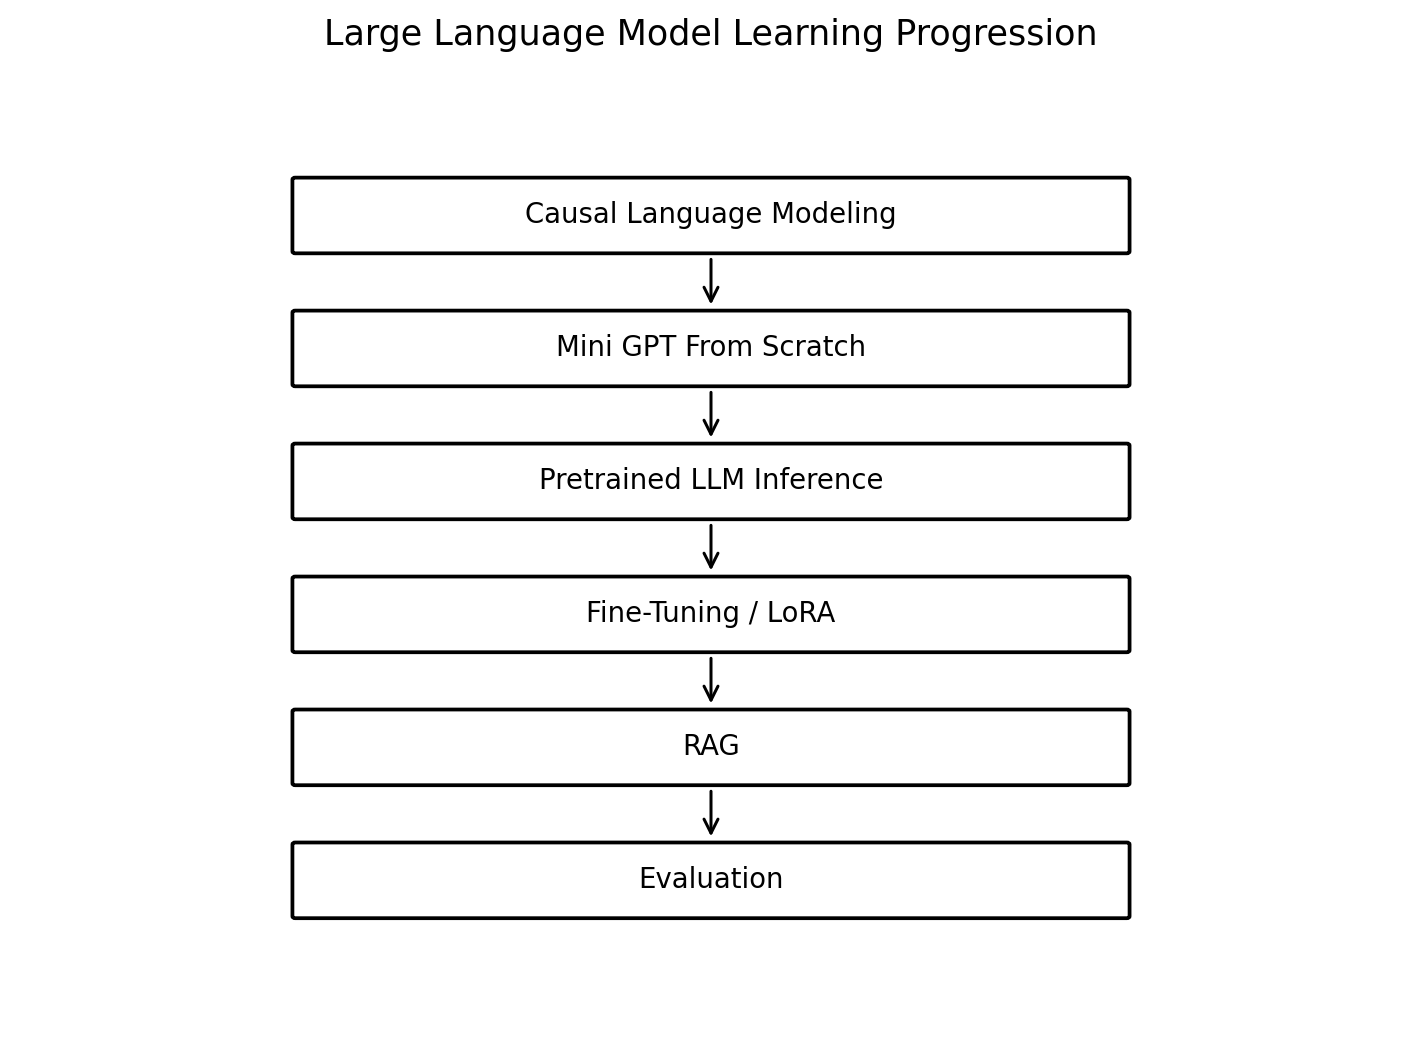

The four notebooks now form one continuous portfolio story:

1. **Causal Language Modeling and GPT From Scratch** — understand the mechanism.
2. **Pretrained LLM Inference and Text Generation** — inspect modern model usage.
3. **Fine-Tuning and LoRA** — efficiently adapt model behavior.
4. **RAG and Evaluation** — build and evaluate a grounded LLM system.

## Key Takeaways

1. RAG gives an LLM an external knowledge path without requiring that all knowledge be stored in model weights.
2. Chunking, embedding quality, similarity search, and top-k selection strongly influence retrieval quality.
3. Cosine similarity provides a transparent baseline for dense retrieval.
4. Retrieval and generation must be evaluated separately.
5. A correct retrieved passage does not guarantee a faithful answer.
6. A fluent answer does not guarantee that retrieval succeeded.
7. RAG system design requires both model understanding and information-retrieval understanding.
8. Failure analysis is essential for diagnosing whether errors come from retrieval, context construction, or generation.